### Statement ###

Solving the problem

$$\begin{align*}
    -k \nabla u &= v\\
    \nabla \cdot v &= 0 \\

    u &= g_D \qquad             &\text{on } \Gamma_D\\
    v &= h = (h_1,\,h_2) \qquad &\text{on } \Gamma_N,
\end{align*}
$$

where $k$ is assumed piecewise smooth. The boundary conditions of $v = (v_1,\,v_2)$ on $\Gamma_N$ then translate to 

$$ \begin{align*}
    \partial_x u &= h_1 \\
    \partial_y u &= h_2
\end{align*}
$$

In [111]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [112]:
import torch
from torch.autograd import grad
from torch.optim.lr_scheduler import ReduceLROnPlateau
import sys
sys.path.append('../..')

from src import train, utils
import src.data.cube_domain as cb
import src.models.expert_discontinuous as ed
import src.models.mlp_model as mm
import src.models.expert_chars as ec


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

L_BOUNDS = [-1.0, -1.0]
U_BOUNDS = [1.0, 1.0]

In [113]:
def k(x: torch.Tensor) -> torch.Tensor:
    return torch.where(torch.norm(x, p=2, dim=1) < 0.5, 1, 2).unsqueeze(1)


def g_D(x: torch.Tensor) -> torch.Tensor:
    return 0.5 * (x[:, 0:1] + 1)


def u_0(x: torch.Tensor) -> torch.Tensor:
    return 1 - x[:, 0:1]**2


def v_0(x: torch.Tensor) -> torch.Tensor:
    shape = 1 - x[:, 1:2]**2                   # (N,1), zero when y=±1
    ones  = torch.ones(x.shape[0], 1, device=x.device)
    return torch.cat([ones, shape], dim=1)       # (N,2)


def h(x: torch.Tensor) -> torch.Tensor:
    return torch.cat([torch.zeros_like(x[:, 0:1]), x[:, 1:2]], dim=1)

In [114]:
def res(u: torch.Tensor, v: torch.Tensor, pde_in: torch.Tensor):
    grad_u = grad(u, pde_in, torch.ones_like(u), create_graph=True)[0]
    
    res_1 = k(pde_in) * grad_u + v
    
    v_1_x = grad(v[:, 0], pde_in, torch.ones_like(v[:, 0]), create_graph=True)[0][:, 0]
    v_2_y = grad(v[:, 1], pde_in, torch.ones_like(v[:, 1]), create_graph=True)[0][:, 1]

    res_2 = v_1_x + v_2_y
    
    return res_1, res_2

In [115]:
def chi(x):
    return torch.where(torch.norm(x, p=2, dim=1) < 0.5, 1, 0).to(torch.float16).unsqueeze(1)

model_ctx_u = mm.ModelContext(
    input_dim=2,
    output_dim=1,
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    layer=[32, 32, 32],
    hard_enforce=True,
    constraint_functions=(g_D, u_0)
)

model_ctx_v_exp = ec.PerCharCtx(
    input_dim=2,
    output_dim=2,
    char_functions=[lambda x: 1, chi],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    hidden_layers_per_output=[[16, 16, 16], [16, 16, 16]],
    hard_enforce=True,
    constraint_functions=(h, v_0),
)

model_ctx_v_smooth = mm.ModelContext(
    input_dim=2,
    output_dim=2,
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    layer=[32, 32, 32],
    hard_enforce=True,
    constraint_functions=(h, v_0)
)

model_ctx_v_disc = mm.ModelContext(
    input_dim=2,
    output_dim=2,
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    layer=[32, 32, 32],
    hard_enforce=True,
    constraint_functions=(h, v_0),
    has_discontinuity=True,
    last_layer_activation='disc'
)

model_u_exp = mm.MLPModel(model_ctx_u).to(device)
model_u_smooth = mm.MLPModel(model_ctx_u).to(device)
model_u_disc = mm.MLPModel(model_ctx_u).to(device)

model_v_exp = ec.PerCharModel(model_ctx_v_exp).to(device)
model_v_smooth =  mm.MLPModel(model_ctx_v_smooth).to(device)
model_v_disc =  mm.MLPModel(model_ctx_v_disc).to(device)

model_combined_exp = ec.MultiModel(model_u_exp, model_v_exp).to(device)
model_combined_smooth = ec.MultiModel(model_u_smooth, model_v_smooth).to(device)
model_combined_disc = ec.MultiModel(model_u_disc, model_v_disc).to(device)

optim_combine_exp = torch.optim.Adam(model_combined_exp.parameters(), lr=5e-4)
optim_combine_smooth = torch.optim.Adam(model_combined_smooth.parameters(), lr=5e-4)
optim_combine_disc = torch.optim.Adam(model_combined_disc.parameters(), lr=5e-4)

In [116]:
import copy

model_init_exp    = copy.deepcopy(model_combined_exp)
model_init_disc   = copy.deepcopy(model_combined_disc)
model_init_smooth = copy.deepcopy(model_combined_smooth)

print("Initial parameter snapshots saved for all three models.")

Initial parameter snapshots saved for all three models.


In [117]:

def loss_combined(model: torch.nn.Module, domain: cb.CubeDomain):
    pde_in = domain.interior.requires_grad_(True)

    pde_out = model(pde_in)
    u = pde_out[:, 0]
    v = pde_out[:, 1:]

    res_1, res_2 = res(u, v, pde_in)
    res_sq = res_1[:, 0]**2 + res_1[:, 1]**2

    loss_1 = torch.mean(res_sq)
    
    loss_2 = torch.mean(res_2**2)

    return [loss_1, loss_2]

In [118]:
domain_ctx = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=2,
    N_int=5_000,
    N_sides=[(0, 0), (0, 0)],
    int_sampling='Latin',
    device=device,
)

domain = cb.CubeDomain(domain_ctx)
print(f"Interior points: {domain.interior.shape}")

Interior points: torch.Size([5000, 2])


In [119]:
train_ctx_combined = train.TrainingContext(
    model=model_combined_exp,
    domain=domain,  
    optimizer=optim_combine_exp,
    loss_fn=loss_combined,
    epochs=20_000,
    monitor_gradient=True,
    monitor_lr=True,
)

loss_exp, loss_comps_exp = train.train_switch_to_lbfgs(train_ctx_combined, lbfgs_lr=0.1, epochs_with_lbfgs=1_000)

train_ctx_combined.model = model_combined_disc
train_ctx_combined.optimizer = optim_combine_disc
loss_disc, loss_comps_disc = train.train_switch_to_lbfgs(train_ctx_combined, lbfgs_lr=0.1, epochs_with_lbfgs=1_000)

train_ctx_combined.model = model_combined_smooth
train_ctx_combined.optimizer = optim_combine_smooth
loss_smooth, loss_comps_smooth = train.train_switch_to_lbfgs(train_ctx_combined, lbfgs_lr=0.1, epochs_with_lbfgs=1_000)


Loss at epoch 1 is: 2.173190116882324. Total gradient norm: inf Current learing rate: 0.0005 
Loss at epoch 100 is: 0.49169808626174927. Total gradient norm: 1.2037509318239912 Current learing rate: 0.0005 
Loss at epoch 200 is: 0.16788798570632935. Total gradient norm: 0.24104935847022446 Current learing rate: 0.0005 
Loss at epoch 300 is: 0.1252514272928238. Total gradient norm: 0.2131069401455214 Current learing rate: 0.0005 
Loss at epoch 400 is: 0.10816895961761475. Total gradient norm: 0.09977644641683023 Current learing rate: 0.0005 
Loss at epoch 500 is: 0.0993085578083992. Total gradient norm: 0.06518110437135269 Current learing rate: 0.0005 
Loss at epoch 600 is: 0.0908244326710701. Total gradient norm: 0.320554645353275 Current learing rate: 0.0005 
Loss at epoch 700 is: 0.08732236921787262. Total gradient norm: 0.21679699662622068 Current learing rate: 0.0005 
Loss at epoch 800 is: 0.08019603788852692. Total gradient norm: 0.03183647603337528 Current learing rate: 0.0005 
L

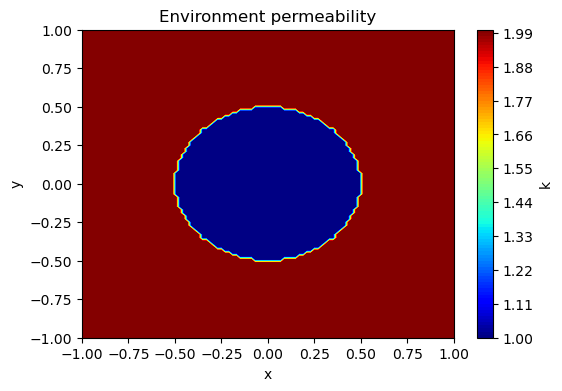

In [120]:
def pde_residuum(pde_input: torch.Tensor, model: torch.nn.Module) -> torch.Tensor:
    u = model(pde_input)[:, 0]
    u_grad = grad(u, pde_input, torch.ones_like(u), create_graph=True)[0]
    u_grad = u_grad
    u_x, u_y = u_grad[:, 0], u_grad[:, 1]
    
    u_xx = grad(u_x, pde_input, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
    u_yy = grad(u_y, pde_input, torch.ones_like(u_y), create_graph=True)[0][:, 1:2]

    return (u_xx + u_yy)

plot_ctx = utils.PlotContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    patches=[],
    titles=["Environment permeability"],
    function_names=["k"],
    colour_map='jet',
    vmin=1,
    vmax=2,
    device=device,
    N=100,
    save_img=False
)

utils.plot_function_on_2d_cube([k], plot_ctx)

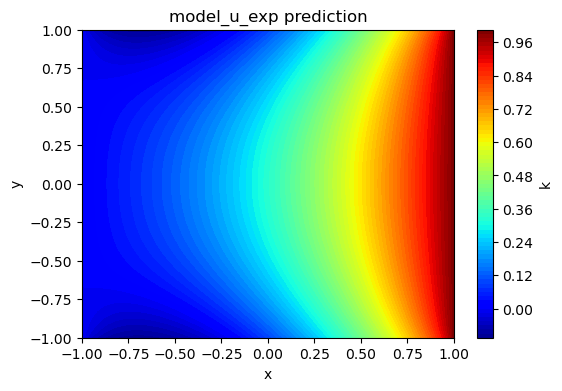

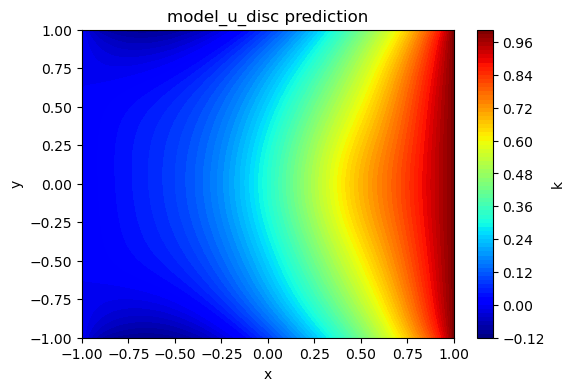

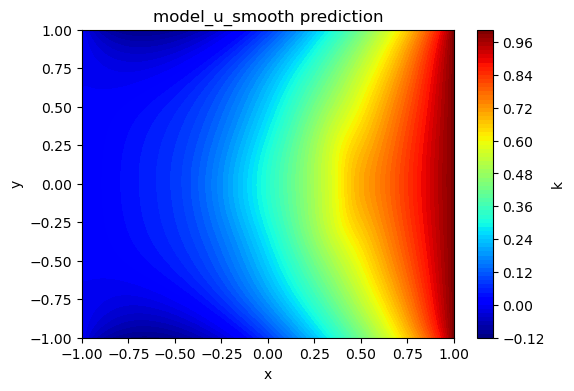

In [121]:
plot_ctx.vmin = -0.12
plot_ctx.vmax = 1

plot_ctx.titles = ['model_u_exp prediction']
utils.plot_function_on_2d_cube([lambda x: model_combined_exp(x)[:, 0]], plot_ctx)

plot_ctx.titles = ['model_u_disc prediction']
utils.plot_function_on_2d_cube([lambda x: model_combined_disc(x)[:, 0]], plot_ctx)

plot_ctx.titles = ['model_u_smooth prediction']
utils.plot_function_on_2d_cube([lambda x: model_combined_smooth(x)[:, 0]], plot_ctx)

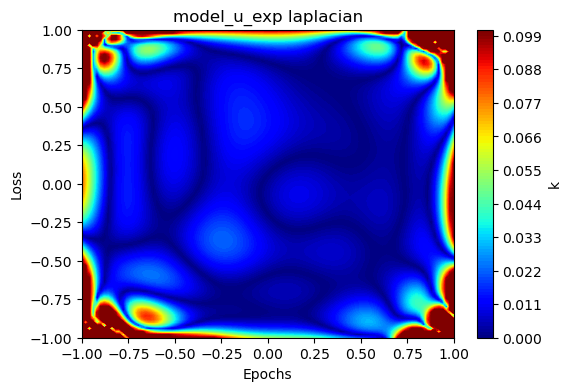

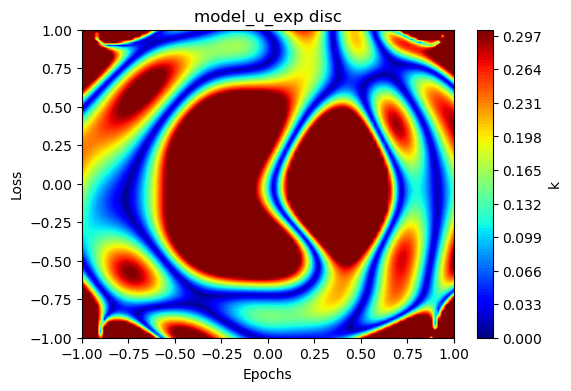

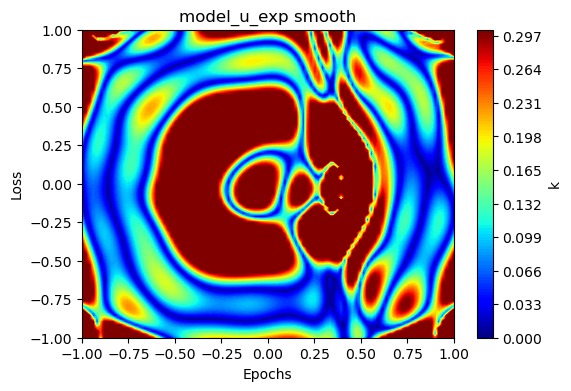

In [131]:
plot_ctx.vmax = 0.1
plot_ctx.vmin = 0.0

plot_ctx.titles = ["model_u_exp laplacian"]
utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(pde_residuum(x.requires_grad_(True), model_combined_exp)), 0.0, 0.1)], plot_ctx)

plot_ctx.vmax = 0.3
plot_ctx.titles = ["model_u_exp disc"]
utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(pde_residuum(x.requires_grad_(True), model_combined_disc)), 0.0, 0.3)], plot_ctx)

plot_ctx.titles = ["model_u_exp smooth"]
utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(pde_residuum(x.requires_grad_(True), model_combined_smooth)), 0.0, 0.3)], plot_ctx)


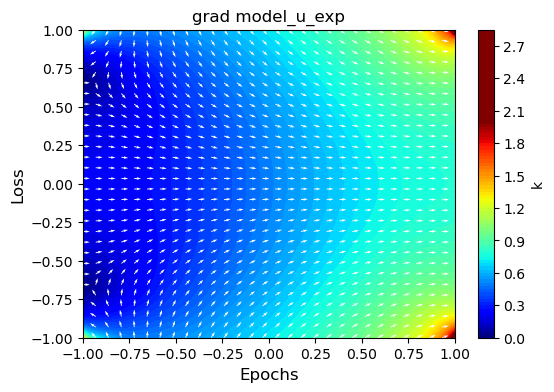

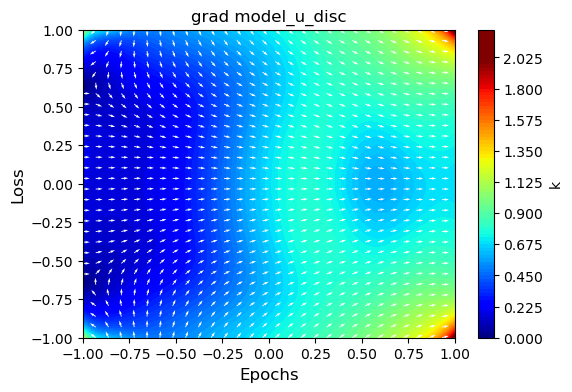

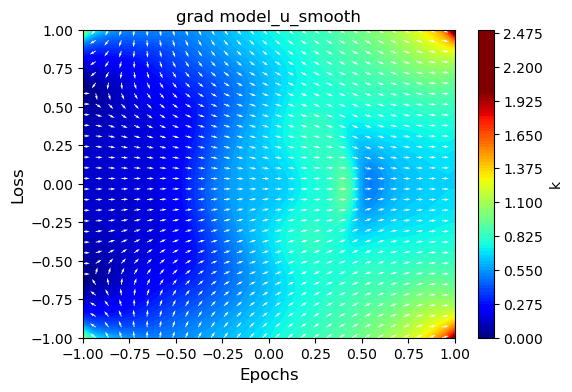

In [132]:

plot_ctx.vmin = 0
plot_ctx.vmax = 2

def heat_flow(x, model):
    x.requires_grad_(True)
    u = model(x)[:, 0]
    
    return grad(u, x, torch.ones_like(u))[0]

plot_ctx.titles = ['grad model_u_exp']
utils.plot_vector_field_2d([lambda x: heat_flow(x, model_combined_exp)], plot_ctx, N=100, n_heigth=30, n_width=30)

plot_ctx.titles = ['grad model_u_disc']
utils.plot_vector_field_2d([lambda x: heat_flow(x, model_combined_disc)], plot_ctx, N=100, n_heigth=30, n_width=30)

plot_ctx.titles = ['grad model_u_smooth']
utils.plot_vector_field_2d([lambda x: heat_flow(x, model_combined_smooth)], plot_ctx, N=100, n_heigth=30, n_width=30)

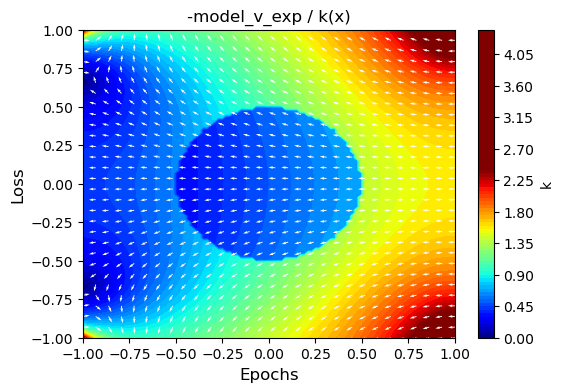

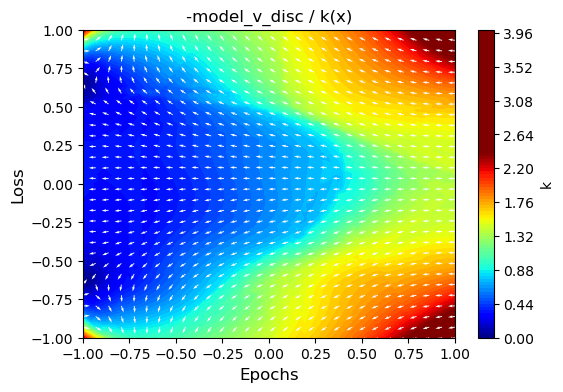

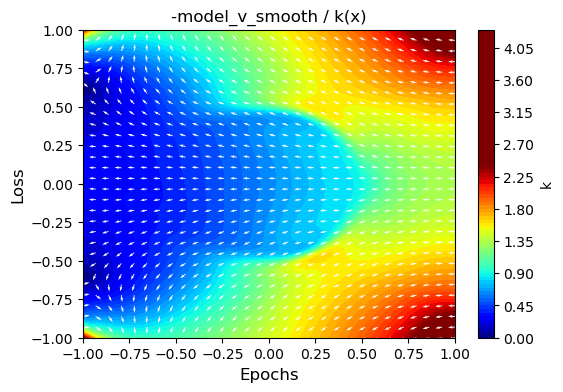

In [133]:

plot_ctx.vmin = 0
plot_ctx.vmax = 2.4

plot_ctx.titles = ['-model_v_exp / k(x)']
utils.plot_vector_field_2d([lambda x: model_combined_exp(x)[:, 1:] ], plot_ctx, N=100, n_heigth=30, n_width=30)

plot_ctx.titles = ['-model_v_disc / k(x)']
utils.plot_vector_field_2d([lambda x: model_combined_disc(x)[:, 1:] ], plot_ctx, N=100, n_heigth=30, n_width=30)

plot_ctx.titles = ['-model_v_smooth / k(x)']
utils.plot_vector_field_2d([lambda x: model_combined_smooth(x)[:, 1:] ], plot_ctx, N=100, n_heigth=30, n_width=30)


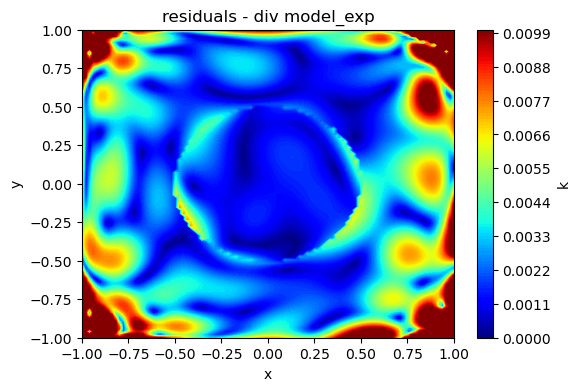

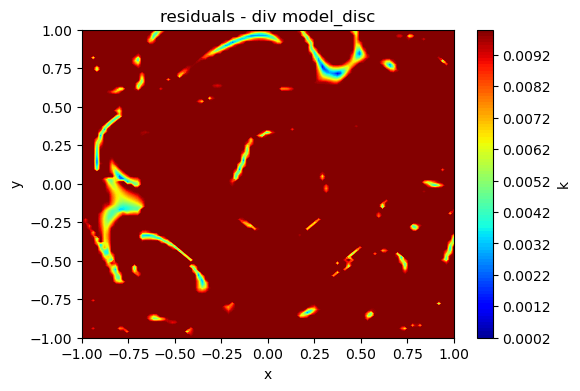

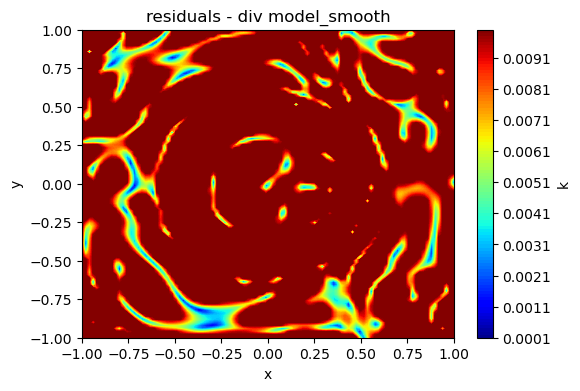

In [125]:
plot_ctx.vmax = 0.01
plot_ctx.vmin = 0.0

plot_ctx.titles = ["Residuals trained"]

def res_div_helper(x, model):
    x.requires_grad_(True)
    out = model(x)
    u = out[:, 0]
    v = out[:, 1:]
    
    res_1, res_2 = res(u, v, x)
        
    return torch.norm(res_1, p=2,dim=1)

plot_ctx.titles = ["residuals - div model_exp"]
utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(res_div_helper(x, model_combined_exp)), 0.0, 0.01)], plot_ctx)

plot_ctx.titles = ["residuals - div model_disc"]
utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(res_div_helper(x, model_combined_disc)), 0.0, 0.01)], plot_ctx)

plot_ctx.titles = ["residuals - div model_smooth"]
utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(res_div_helper(x, model_combined_smooth)), 0.0, 0.01)], plot_ctx)

In [135]:
from src.calculus import L2_norm

zero_2d = lambda x: torch.zeros(x.shape[0], 2, device=x.device)
zero_1d = lambda x: torch.zeros(x.shape[0], 1, device=x.device)

def make_res1_fn(model):
    def f(x):
        x = x.requires_grad_(True)
        out = model(x)
        u, v = out[:, 0], out[:, 1:]
        r1, _ = res(u, v, x)
        return r1  # (N, 2)
    return f

def make_res2_fn(model):
    def f(x):
        x = x.requires_grad_(True)
        out = model(x)
        u, v = out[:, 0], out[:, 1:]
        _, r2 = res(u, v, x)
        return r2.unsqueeze(1)  # (N, 1)
    return f

models_named = {
    "combined_exp":    model_combined_exp,
    "combined_disc":   model_combined_disc,
    "combined_smooth": model_combined_smooth,
}

print(f"{'Model':<18}  {'L2 ||res1||':>12}  {'L2 ||res2||':>12}")
print("-" * 46)
for name, model in models_named.items():
    l2_r1 = L2_norm(make_res1_fn(model), zero_2d, input_dim=2, u_bounds=U_BOUNDS, l_bounds=L_BOUNDS, device=str(device), n=50)
    l2_r2 = L2_norm(make_res2_fn(model), zero_1d, input_dim=2, u_bounds=U_BOUNDS, l_bounds=L_BOUNDS, device=str(device), n=50)
    print(f"{name:<18}  {l2_r1.item():>12.6e}  {l2_r2.item():>12.6e}")


Model                L2 ||res1||   L2 ||res2||
----------------------------------------------
combined_exp        3.475470e-02  2.990495e-02
combined_disc       1.767516e-01  3.396903e-02
combined_smooth     1.105525e-01  2.764679e-02


/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/darcy/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


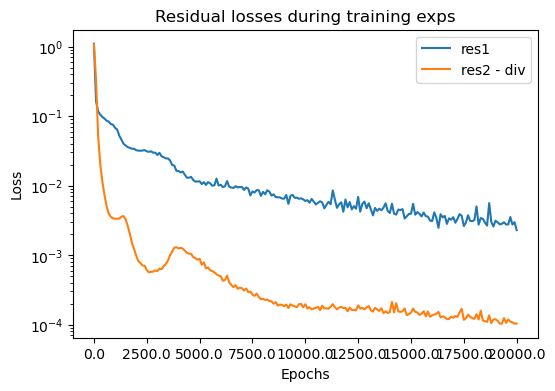

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/darcy/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


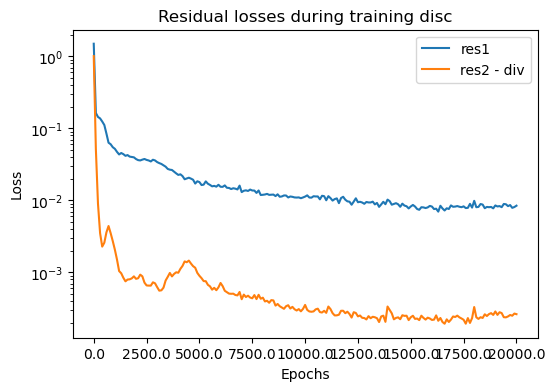

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/darcy/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


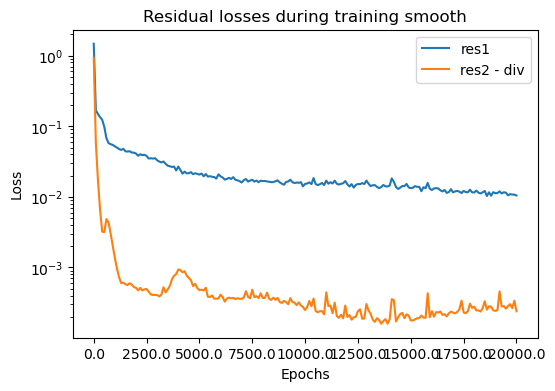

In [126]:
plot_ctx.y_label = 'Loss'
plot_ctx.x_label = 'Epochs'

plot_ctx.titles = ['Residual losses during training exps']
utils.plot_loss_values({"res1": loss_comps_exp[0],
                        "res2 - div": loss_comps_exp[1]}, plot_ctx)

plot_ctx.titles = ['Residual losses during training disc']
utils.plot_loss_values({"res1": loss_comps_disc[0],
                        "res2 - div": loss_comps_disc[1]}, plot_ctx)

plot_ctx.titles = ['Residual losses during training smooth']
utils.plot_loss_values({"res1": loss_comps_smooth[0],
                        "res2 - div": loss_comps_smooth[1]}, plot_ctx)

Errors w.r.t. FEM ground truth:
  combined_exp      L2=2.365437e+00  RelL2=5.129397e-02  RMSE=2.365437e-02
  combined_disc     L2=5.945786e-01  RelL2=1.289330e-02  RMSE=5.945786e-03
  combined_smooth   L2=1.876430e-01  RelL2=4.068995e-03  RMSE=1.876430e-03


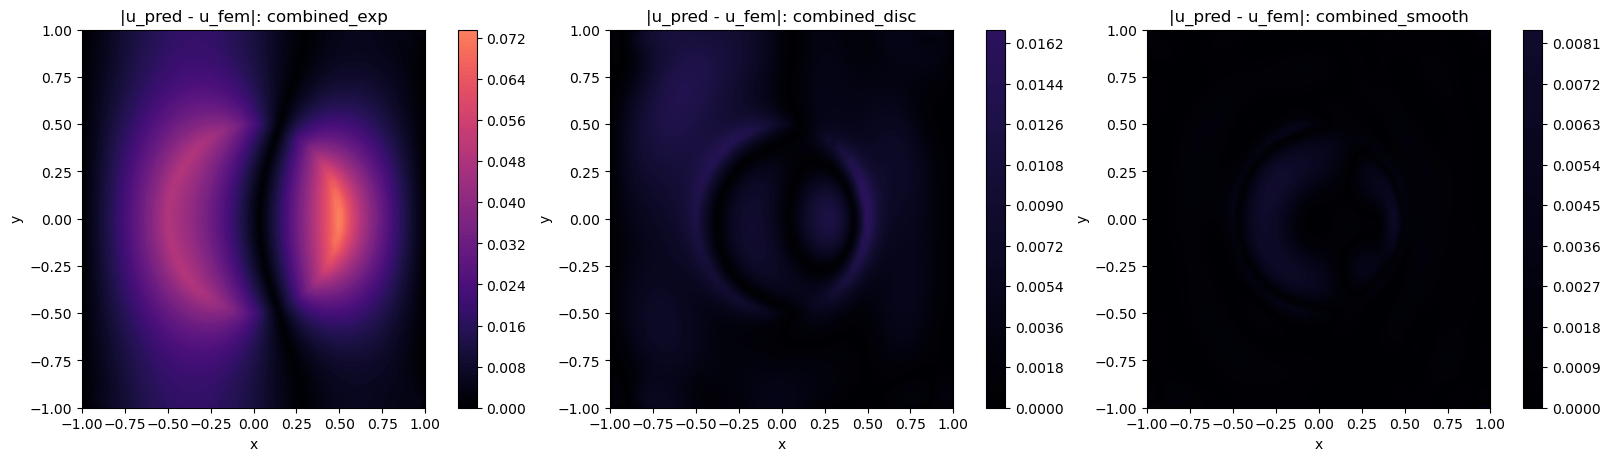

In [127]:
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt

# ── Load FEM reference solution ─────────────────────────────────────────────
with h5py.File("darcy_solution.h5", "r") as f:
    xy_np = f["samples/xy"][:]         # (N, 2)
    u_fem = f["samples/u_interp"][:]   # (N,)

xy_fem  = torch.tensor(xy_np, dtype=torch.float32, device=device)
u_fem_t = torch.tensor(u_fem, dtype=torch.float32, device=device)  # (N,)

models = {
    "combined_exp": model_combined_exp,
    "combined_disc": model_combined_disc,
    "combined_smooth": model_combined_smooth,
}

u_true_norm = torch.linalg.vector_norm(u_fem_t, ord=2)

print("Errors w.r.t. FEM ground truth:")
err_maps = {}

for name, model in models.items():
    model.eval()
    with torch.no_grad():
        u_pred = model(xy_fem)[:, 0]               # (N,)
        err = u_pred - u_fem_t                     # signed error
        abs_err = err.abs()

        l2_abs = torch.linalg.vector_norm(abs_err, ord=2)
        rel_l2 = l2_abs / (u_true_norm + 1e-12)
        rmse = torch.sqrt(torch.mean(err**2))

    err_maps[name] = abs_err.detach().cpu().numpy()
    print(f"  {name:<16}  L2={l2_abs.item():.6e}  RelL2={rel_l2.item():.6e}  RMSE={rmse.item():.6e}")

# ── Plot absolute error fields on FEM grid ──────────────────────────────────
xs = np.unique(xy_np[:, 0])
ys = np.unique(xy_np[:, 1])
nx, ny = len(xs), len(ys)

X = xy_np[:, 0].reshape(nx, ny)
Y = xy_np[:, 1].reshape(nx, ny)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
vmax = max(np.max(err_maps[k]) for k in err_maps.keys())

for ax, (name, e) in zip(axes, err_maps.items()):
    E = e.reshape(nx, ny)
    c = ax.contourf(X, Y, E, levels=100, cmap="magma", vmin=0.0, vmax=0.1)
    ax.set_title(f"|u_pred - u_fem|: {name}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(c, ax=ax)

plt.show()

In [128]:
def max_param_drift(model: torch.nn.Module, init_model: torch.nn.Module) -> float:
    learned = model.state_dict()
    initial = init_model.state_dict()
    return max(
        (learned[k].float() - initial[k].float()).abs().max().item()
        for k in learned
    )

pairs = {
    "combined_exp":    (model_combined_exp,    model_init_exp),
    "combined_disc":   (model_combined_disc,   model_init_disc),
    "combined_smooth": (model_combined_smooth, model_init_smooth),
}

print(f"{'Model':<18}  {'Max |Δ param|':>14}  {'Mean |Δ param|':>15}")
print("-" * 52)
for name, (trained, init) in pairs.items():
    learned = trained.state_dict()
    initial = init.state_dict()
    deltas = [(learned[k].float() - initial[k].float()).abs() for k in learned]
    max_drift  = max(d.max().item() for d in deltas)
    mean_drift = sum(d.mean().item() for d in deltas) / len(deltas)
    print(f"{name:<18}  {max_drift:>14.6e}  {mean_drift:>15.6e}")


Model                Max |Δ param|   Mean |Δ param|
----------------------------------------------------
combined_exp          3.116803e+00     1.624715e-01
combined_disc         2.784418e+00     8.288072e-02
combined_smooth       1.929538e+00     1.303391e-01
